<a href="https://colab.research.google.com/github/shweta1sen/NumPy-Basics/blob/main/Lasso_Regression_Assignment_1_March6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [582]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # scikit-learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score


In [583]:
# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Path to dataset files::", path)
dataset = pd.read_csv(f'{path}/Housing.csv')

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files:: /kaggle/input/housing-prices-dataset


In [584]:
categorical_columns = dataset.select_dtypes(include=['object']).columns


In [585]:
print('Categorical columns :', len(categorical_columns))

Categorical columns : 7


In [586]:
integer_columns = dataset.select_dtypes(include=['int64']).columns


In [587]:
categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [588]:
integer_columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

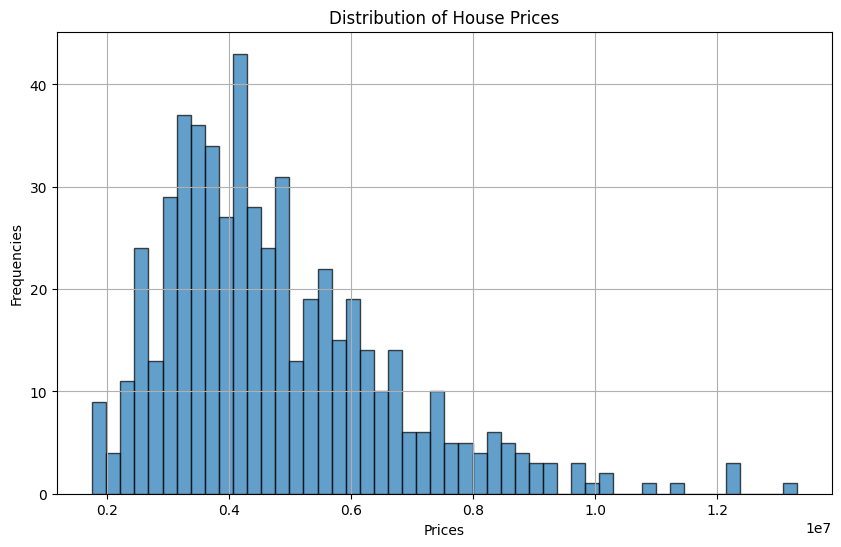

In [589]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['price'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Prices')
plt.xlabel('Prices')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [590]:
#reproducibility
np.random.seed(42)

# **Data Processing for the model**


In [591]:
# target output
y = dataset['price']
#X = dataset[['area', 'bedrooms','bathrooms','stories','mainroad','guestroom']]

# taking all columns for regularization
X = dataset[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'airconditioning', 'parking', 'furnishingstatus','hotwaterheating','prefarea']]

X.shape, y.shape

((545, 12), (545,))

In [592]:
# splitting the datasaet into training and validation
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, random_state=42)

In [593]:
X_Train.shape, X_Test.shape

((436, 12), (109, 12))

In [594]:
categorical_columns = X_Train.select_dtypes(include=['object']).columns
print("Categorical columns : ", len(categorical_columns), ":", categorical_columns)

integer_columns = X_Train.select_dtypes(include=['int64']).columns
print("Integer columns : ", len(integer_columns), ":", integer_columns)



Categorical columns :  7 : Index(['mainroad', 'guestroom', 'basement', 'airconditioning',
       'furnishingstatus', 'hotwaterheating', 'prefarea'],
      dtype='object')
Integer columns :  5 : Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


In [595]:
#assign these columns to the traning & test dataset
X_Train_Cat = X_Train[categorical_columns]
X_Test_Cat = X_Test[categorical_columns]

X_Train_Int = X_Train[integer_columns]
X_Test_Int = X_Test[integer_columns]


In [596]:
X_Train_Cat.shape, X_Test_Cat.shape

((436, 7), (109, 7))

In [597]:
#using one hot encoding to make the category data into the numeric data

encoder = OneHotEncoder(sparse_output=False, drop='first')
X_Train_Cat_Encoded = encoder.fit_transform(X_Train_Cat)
X_Test_Cat_Enoded = encoder.fit_transform(X_Test_Cat)

In [598]:
X_Train_Cat.head(5)

,mainroad,guestroom,basement,airconditioning,furnishingstatus,hotwaterheating,prefarea
46,yes,no,no,yes,furnished,no,no
93,yes,no,yes,yes,semi-furnished,no,no
335,yes,no,yes,yes,furnished,no,no
412,yes,no,yes,no,unfurnished,no,yes
471,yes,no,no,no,unfurnished,no,no


In [599]:
X_Train_Cat_Encoded[:5, :]

array([[1., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 1., 1., 1., 0., 0., 0.],
       [1., 0., 1., 1., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 0., 1., 0., 0.]])

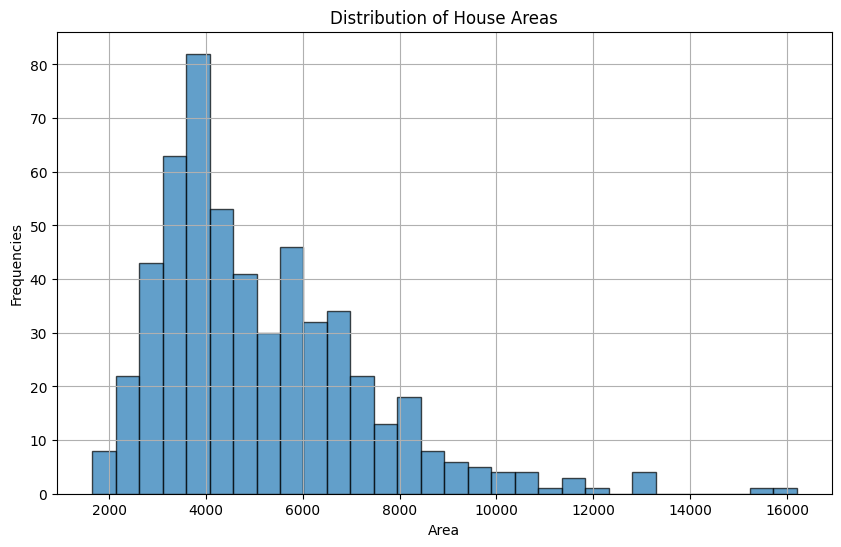

In [600]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['area'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Areas')
plt.xlabel('Area')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [601]:
#scaling the area to avoid penalizing the large coefficients

standardScale = StandardScaler() # z = (X_val - mean) / std  where mean=0, std=1

X_Train_Int_Scaled = standardScale.fit_transform(X_Train_Int) # computes - Mean, std -> 0,1
X_Test_Int_Scaled = standardScale.fit_transform(X_Test_Int)

In [602]:
#Scaling the categorical columns as well
X_Train_Cat_Scaled = standardScale.fit_transform(X_Train_Cat_Encoded)
X_Test_Cat_Scaled = standardScale.fit_transform(X_Test_Cat_Enoded)

In [603]:
X_Train_Int_Scaled[:5, :]

array([[ 0.38416819,  0.05527092,  1.53917323,  2.58764353,  0.36795665],
       [ 0.9291807 ,  0.05527092,  1.53917323, -0.91249891,  2.70998729],
       [-0.60775457, -1.28351359, -0.5579503 , -0.91249891,  1.53897197],
       [-1.15549214,  0.05527092, -0.5579503 ,  0.25421524, -0.80305867],
       [-0.63773026,  0.05527092, -0.5579503 ,  0.25421524, -0.80305867]])

In [604]:
X_Train_Cat_Scaled[:5, :]

array([[ 0.40715525, -0.46677307, -0.74642003,  1.50124327, -0.870669  ,
        -0.67690027, -0.23052136, -0.55262032],
       [ 0.40715525, -0.46677307,  1.33972825,  1.50124327,  1.14854209,
        -0.67690027, -0.23052136, -0.55262032],
       [ 0.40715525, -0.46677307,  1.33972825,  1.50124327, -0.870669  ,
        -0.67690027, -0.23052136, -0.55262032],
       [ 0.40715525, -0.46677307,  1.33972825, -0.66611456, -0.870669  ,
         1.47732249, -0.23052136,  1.80956067],
       [ 0.40715525, -0.46677307, -0.74642003, -0.66611456, -0.870669  ,
         1.47732249, -0.23052136, -0.55262032]])

In [605]:
X_Train_Cat_Scaled.shape, X_Test_Cat_Scaled.shape

((436, 8), (109, 8))

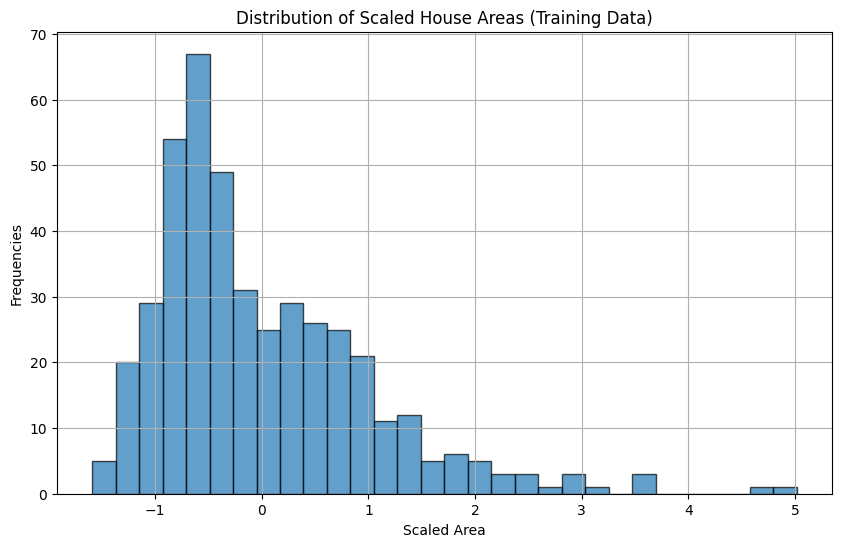

In [606]:
plt.figure(figsize=(10, 6))
plt.hist(X_Train_Int_Scaled[:, 0], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Scaled House Areas (Training Data)')
plt.xlabel('Scaled Area')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [607]:
X_Train_Int_Scaled[:5, 0]

array([ 0.38416819,  0.9291807 , -0.60775457, -1.15549214, -0.63773026])

In [608]:
print('Mean val: ', X_Train_Int_Scaled[:, 0].mean())
print('Std val: ', X_Train_Int_Scaled[:, 0].std())

Mean val:  1.2222638803212733e-16
Std val:  1.0000000000000002


In [609]:
# combined the encoded data and the scaled data into final dataset
X_Train_Final = np.concatenate((X_Train_Cat_Scaled, X_Train_Int_Scaled), axis=1)
X_Test_Final = np.concatenate((X_Test_Cat_Scaled, X_Test_Int_Scaled), axis=1)

X_Train_Final.shape, X_Test_Final.shape

((436, 13), (109, 13))

This completes the data pre-processing. Now comes model development

In [610]:
class LassoRegression:
  def __init__(self, X, y, learningRate, epoch, l1Penalty):
    # number of samples
    self.samples, self.features = X.shape
    self.X = X
    self.y = y
    self.alpha = learningRate
    self.epoch = epoch
    self.l1Penalty = l1Penalty

    # initiate gradients and weights
    self.bias = 0
    self.wt = np.zeros(self.features)
    self.gradient_b = 0
    self.gradient_w = np.zeros(self.features)
    self.loss_history = []


  # compute mean square error loss function
  def compute_loss(self):

    error = self.y - self.y_hat # dimension N X 1
    loss = [1/(self.samples) * np.dot(error.T, error) ] + [ self.l1Penalty * np.sum(self.wt) ]

    # scalar from formula : 1/N sum(y-yhat)^2 + lambda * np.sum(self.wt)
    # extra term for Lasso regularisation

    return loss

  # next comes gradients

  def compute_gradient(self):
    self.gradient_b = -(2/self.samples) * np.sum(self.y - self.y_hat)
    self.gradient_w = [ -(2/self.samples) * np.sum(np.dot(self.X.T, (self.y - self.y_hat) ))] + (self.l1Penalty * np.sign(self.wt)) # additional term for the regularization term


# forward pass > calculate loss > compute gradient > update weights
# run validation loop > decision

  def train(self, show_training_updates = False):  # if the training needs visualisation, make this True
    self.loss_history = []

    for i in range(self.epoch):
      #predict and calculate loss
      self.y_hat = np.dot(self.X, self.wt) + self.bias # y = w.x + b
      loss = self.compute_loss()
      self.loss_history.append(loss)

      #perform optimisation
      self.compute_gradient()

      #update weights
      self.bias = self.bias - (self.alpha * self.gradient_b)
      self.wt = self.wt - (self.alpha * self.gradient_w)
      print(f'Training Loss:: {loss}, Weight: {self.wt}, Bias: {self.bias}, epoch: {i}')


      if show_training_updates:
        plt.figure(figsize=(10, 6), dpi=80)
        plt.title('Training Update Epoch: {}'.format(str(i+1)))
        plt.scatter(self.y, self.y_hat, alpha=0.7)
        plt.plot([self.y.min(), self.y.max()], [self.y_hat.min(), self.y_hat.max()], 'r--', lw=2)
        plt.show()


    return self.bias, self.wt, self.loss_history


  #Predict values for new data
  def predict(self, X):
    return np.dot(X, self.wt) + self.bias


In [611]:
#Training the model

#setting hyper parameters
learningRate = 0.01
epochs = 500
_lambda = 1e-9


# initiating the model
model = LassoRegression(X_Train_Final, y_Train, learningRate, epochs, _lambda)

In [612]:
bias, weights, loss_history = model.train(show_training_updates=False)

Training Loss:: [np.float64(25234792406487.617), np.float64(0.0)], Weight: [126894.59365979 126894.59365979 126894.59365979 126894.59365979
 126894.59365979 126894.59365979 126894.59365979 126894.59365979
 126894.59365979 126894.59365979 126894.59365979 126894.59365979
 126894.59365979], Bias: 94130.54770642203, epoch: 0
Training Loss:: [np.float64(23113368771932.52), np.float64(0.0016496297175773002)], Weight: [196104.20862394 196104.20862394 196104.20862394 196104.20862394
 196104.20862394 196104.20862394 196104.20862394 196104.20862394
 196104.20862394 196104.20862394 196104.20862394 196104.20862394
 196104.20862394], Bias: 186378.48445871563, epoch: 1
Training Loss:: [np.float64(21900786765919.633), np.float64(0.0025493547121112465)], Weight: [233851.84361246 233851.84361246 233851.84361246 233851.84361246
 233851.84361246 233851.84361246 233851.84361246 233851.84361246
 233851.84361246 233851.84361246 233851.84361246 233851.84361246
 233851.84361246], Bias: 276781.46247596334, epo

In [613]:
weights

array([279140.91786429, 279140.91786429, 279140.91786429, 279140.91786429,
       279140.91786429, 279140.91786429, 279140.91786429, 279140.91786429,
       279140.91786429, 279140.91786429, 279140.91786429, 279140.91786429,
       279140.91786429])

In [614]:
bias

np.float64(4706334.304811557)

In [615]:
title_with_LR = 'Training Loss over Epochs with Learning Rate: ' + str(learningRate) + ' and Lambda: ' + str(_lambda)
print(title_with_LR)

Training Loss over Epochs with Learning Rate: 0.01 and Lambda: 1e-09


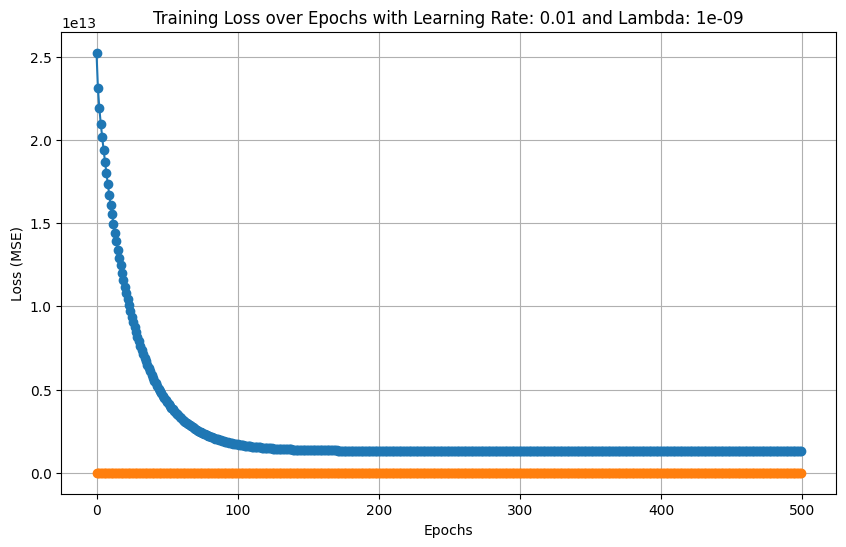

In [616]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, marker='o', linestyle='-',)
plt.title(title_with_LR)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

In [617]:
# MODEL TESTING NOW
y_Pred = model.predict(X_Test_Final)

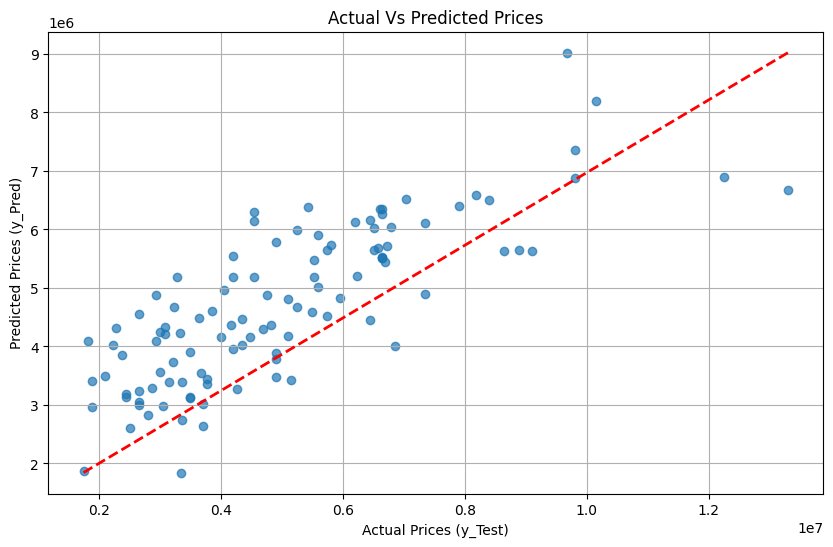

In [618]:
plt.figure(figsize=(10, 6))
plt.scatter(y_Test, y_Pred, alpha=0.7)
plt.plot([y_Test.min(), y_Test.max()], [y_Pred.min(), y_Pred.max()], 'r--', lw=2)
plt.title('Actual Vs Predicted Prices')
plt.xlabel('Actual Prices (y_Test)')
plt.ylabel('Predicted Prices (y_Pred)')
plt.grid(True)
plt.show()

In [619]:
r2 = r2_score(y_Test, y_Pred)
print(f'R2 Score: {r2}')

# R2 Score: -4.337271654878612 with LR = 0.0001 and epoch = 500
# R2 Score: 0.27976470103235296 with LR = 0.01
# R2 Score: 0.49024587566049915 with LR = 0.1
# R2 Score: 0.4902458576248506 with LR = 0.01 and epoch = 5000

R2 Score: 0.5713575548765781
